# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inception Network

In this notebook we build a model of the Inception network and apply it to the configuration matrix of CICY 4-folds.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import json
import joblib
from joblib import Parallel, delayed
from nn_tools.utils.plotutils import *
from nn_tools.utils.datacreate import *
from nn_tools.utils.dirstruct import *
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *
from IPython.display import Image

In [2]:
random_state = 123
np.random.seed(random_state)
tf.random.set_seed(random_state)

## Create a Saving Directory

Each model will be assigned to a different directory based on the time of running.

In [3]:
img_dir, mod_dir = dir_struct(prefix='inception_cnnonly', dirs=['img', 'models'])

Current working directories:

  ./img/inception_cnnonly_20201212_112239
  ./models/inception_cnnonly_20201212_112239


## Parameters

Throughout the notebook we will use certain parameters to be able to automate the procedure.

The first set of parameters is needed to process the input data:

- `aux_output`: whether to use an auxiliary regression output in the model (i.e. a copy of the Hodge numbers to stabilize the weights),
- `aux_suff`: the suffix to add to the outputs names,
- `outliers`: tuple/list containing the quantiles corresponding to the outliers (set (0, 1) to avoid removing them),
- `rescale`: whether to rescale the matrices in $[0,1]$.

In [31]:
parameters = {'aux_output': False,
              'aux_suff':   'aux',
              'outliers':   (0.0, 1.0),
              'rescale':    False
             }

with open(os.path.join(mod_dir, 'parameters.json'), 'w') as f:
    json.dump(parameters, f)

## Load the Dataset

We then download the JSON file containing the configuration matrix and the Hodge numbers of the CICY.

In [32]:
df, (n_rows, n_cols) = load_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz', orient='index')

Size of the dataset: 905684 rows, 5 columns.


We then split it into train, validation and test sets:

In [33]:
df_splits = {'train_split': 0.95, 'val_split': 0.5}
with open(os.path.join(mod_dir, 'train_ratio.json'), 'w') as f:
    json.dump(df_splits, f)

(df_train, df_val, df_test), (n_train, n_val, n_test) = train_test(df, df_splits)

assert n_train + n_val + n_test == n_rows, 'Dimensions do not add up to the original size!'

In [34]:
del df

## Outliers in the Training Set

We then study the outliers in the training set:

In [35]:
low, high = parameters['outliers']
outliers  = df_train.quantile([low, high])

outliers

,h11,h21,h22,h31
0.0,1.0,0.0,204.0,20.0
1.0,24.0,33.0,1752.0,426.0


In [36]:
if 0.0 < low < high < 1.0:
    df_train, n_train_pruned = remove_outliers(df_train, outliers=outliers)

## Rescale the Matrices

We then rescale the matrices in the sets to improve the deep learning results:

In [37]:
rescaling = {'min': df_train['matrix'].apply(lambda x: np.min(x)).min(),
             'max': df_train['matrix'].apply(lambda x: np.max(x)).max()
            } if parameters['rescale'] else None

## Feature and Label Creation

We then create the features and the labels.

In [38]:
reshape = np.shape(df_train['matrix'].iloc[0]) + (1,)

In [39]:
X_train, X_val, X_test = Parallel(n_jobs=-1)\
                         (delayed(lambda d: create_features(d['matrix'], rescaling=rescaling, reshape=reshape))(df) \
                          for df in [df_train, df_val, df_test]
                         )

In [40]:
y_train, y_val, y_test = Parallel(n_jobs=-1)\
                         (delayed(lambda d: create_labels(d[['h11', 'h21', 'h31', 'h22']]))(df) \
                          for df in [df_train, df_val, df_test]
                         )

In [41]:
if parameters['aux_output']:
    y_aux_train, y_aux_val, y_aux_test = Parallel(n_jobs=-1)\
                                         (delayed(lambda d: create_labels(d[['h11', 'h21', 'h31', 'h22']], suff=parameters['aux_suff']))(df) \
                                          for df in [df_train, df_val, df_test]
                                         )
    y_train.update(y_aux_train)
    y_val.update(y_aux_val)
    y_test.update(y_aux_test)

In [42]:
del df_train, df_val, df_test

## Save Training Data to File

We finally save the training data to file in order to have a different notebook compute the predictions.

In [43]:
joblib.dump(X_train, os.path.join(mod_dir, 'X_train.joblib'))
joblib.dump(X_val, os.path.join(mod_dir, 'X_val.joblib'))
joblib.dump(X_test, os.path.join(mod_dir, 'X_test.joblib'))
    
joblib.dump(y_train, os.path.join(mod_dir, 'y_train.joblib'))
joblib.dump(y_val, os.path.join(mod_dir, 'y_val.joblib'))
joblib.dump(y_test, os.path.join(mod_dir, 'y_test.joblib'))

['./models/inception_cnnonly_20201212_112239/y_test.joblib']

## Inception Model

We then start to build the Inception model to be trained on the configuration matrices.

## Parameters

The second set of parameters concerns the neural network architecture:

- `input_shape`: tuple/list containing the shape of the input tensor,
- `name`: the name of the input tensor (to be associated with the input dictionary),
- `learning_rate`: the shrinking parameter (Adam optimiser),
- `output_names`: the names of the output tensors (to be associated with the output dictionary),
- `conv_1b1`: add bottleneck layers ($1 \times 1$ convolutions) to normalise the number of filters,
- `conv_layers`: list of filters per layer of the convolution (prefer large layers rather than number for speed),
- `conv_alpha`: slope of the LeakyReLU activation (0.0 = ReLU) in the convolutional network,
- `conv_class`: tuple/list or int containing the size of a square convolution to add in the inception module,
- `conv_single`: add a standalone $1 \times 1$ convolution in the inception module,
- `conv_red`: int containing the filters of the bottleneck layer ($1 \times 1$ convolution) at the end of the inception module,
- `feat_map`: length of the feature map before flattenisation,
- `recurrent`: make the network a ResNet,
- `fc_layers`: list of units per layers of a fully connected top part of the network,
- `fc_alpha`: slope of the LeakyReLU activation (0.0 = ReLU) in the fully connected network,
- `dropout`: dropout rate between ConvNet and fully connected network ($\le 0$ to deactivate),
- `full_dropout`: dropout rate after every layer (both convolutional and fully connected, $\le 0$ to deactivate),
- `batchnorm`: momentum of the batch normalisation ($\le 0$ to deactivate),
- `last_relu`: whether to use ReLU activation in the output layer,
- `loss_weights`: weights of the outputs (must be the same length as `output_names`),
- `l1_reg`: $\ell_1$ regularisation factor,
- `l2_reg`: $\ell_2$ regularisation factor,
- `auxiliary_fc`: list of auxiliary fully connected layers (see later for an explanation),
- `auxiliary_alpha`: slope of the LeakyReLU activation (0.0 = ReLU) in the fully connected auxiliary network,
- `auxiliary_last_relu`: whether to use ReLU activation in the auxiliary output,
- `auxiliary_suff`: suffix to add to the `output_names` for the auxiliary output,
- `output_layers`: whether to include output layers in the model (False if this is only part of a more complex architecture),
- `random_state`: the random state.

The difference between `fc_layers` and `auxiliary_fc` is the following:

- `fc_layers`:
```
    INPUT ---> CNN ---> FC ---> OUTPUT
                |                 |   
                |                 |   
             BACKPROP <-------- LOSS  
```

             
- `auxiliary_fc`:
```
    INPUT ---> CNN ---> (FC) ---> OUTPUT ---> AUX FC ---> AUX OUTPUT
                |                   |                         |     
                |                   |                         |     
             BACKPROP -----<----- LOSS                      LOSS    
                |                                             |     
                |                                             |     
                \----------------------<----------------------/     
```

                
In other words the original output has the role of a stabilising function approximator (as in the [original paper by Google](https://arxiv.org/abs/1409.4842)).
This way the network learn a good approximation in `OUTPUT` and then refines it using the auxiliary fully connected network (this way it should also learn the relations between the Hodge numbers).

In [44]:
model_data = {'input_shape':         reshape,
              'name':                'matrix',
              'learning_rate':       1.0e-3,
              'output_names':        ['h11', 'h21', 'h31', 'h22'],
              'conv_1b1':            False,
              'conv_layers':         [32, 64, 32],
              'conv_alpha':          0.0,
              'conv_class':          None,
              'conv_single':         False,
              'conv_red':            0,
              'feat_map':            0,
              'recurrent':           False,
              'fc_layers':           [],
              'fc_alpha':            0.0,
              'dropout':             0.2,
              'full_dropout':        0.01,
              'batchnorm':           0.99,
              'last_relu':           True,
              'loss_weights':        [0.15, 0.15, 0.30, 0.40],
              'l1_reg':              1.0e-4,
              'l2_reg':              1.0e-4,
              'auxiliary_fc':        [4] if parameters['aux_output'] else None,
              'auxiliary_alpha':     0.0,
              'auxiliary_last_relu': True,
              'auxiliary_suff':      parameters['aux_suff'],
              'output_layers':       True,
              'random_state':        random_state
             }

with open(os.path.join(mod_dir, 'model_data.json'), 'w') as f:
    json.dump(model_data, f)

### Build the Model

In [45]:
inception = nn_inception(**model_data)
inception.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 32)   544         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 32)   672         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 32)   0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

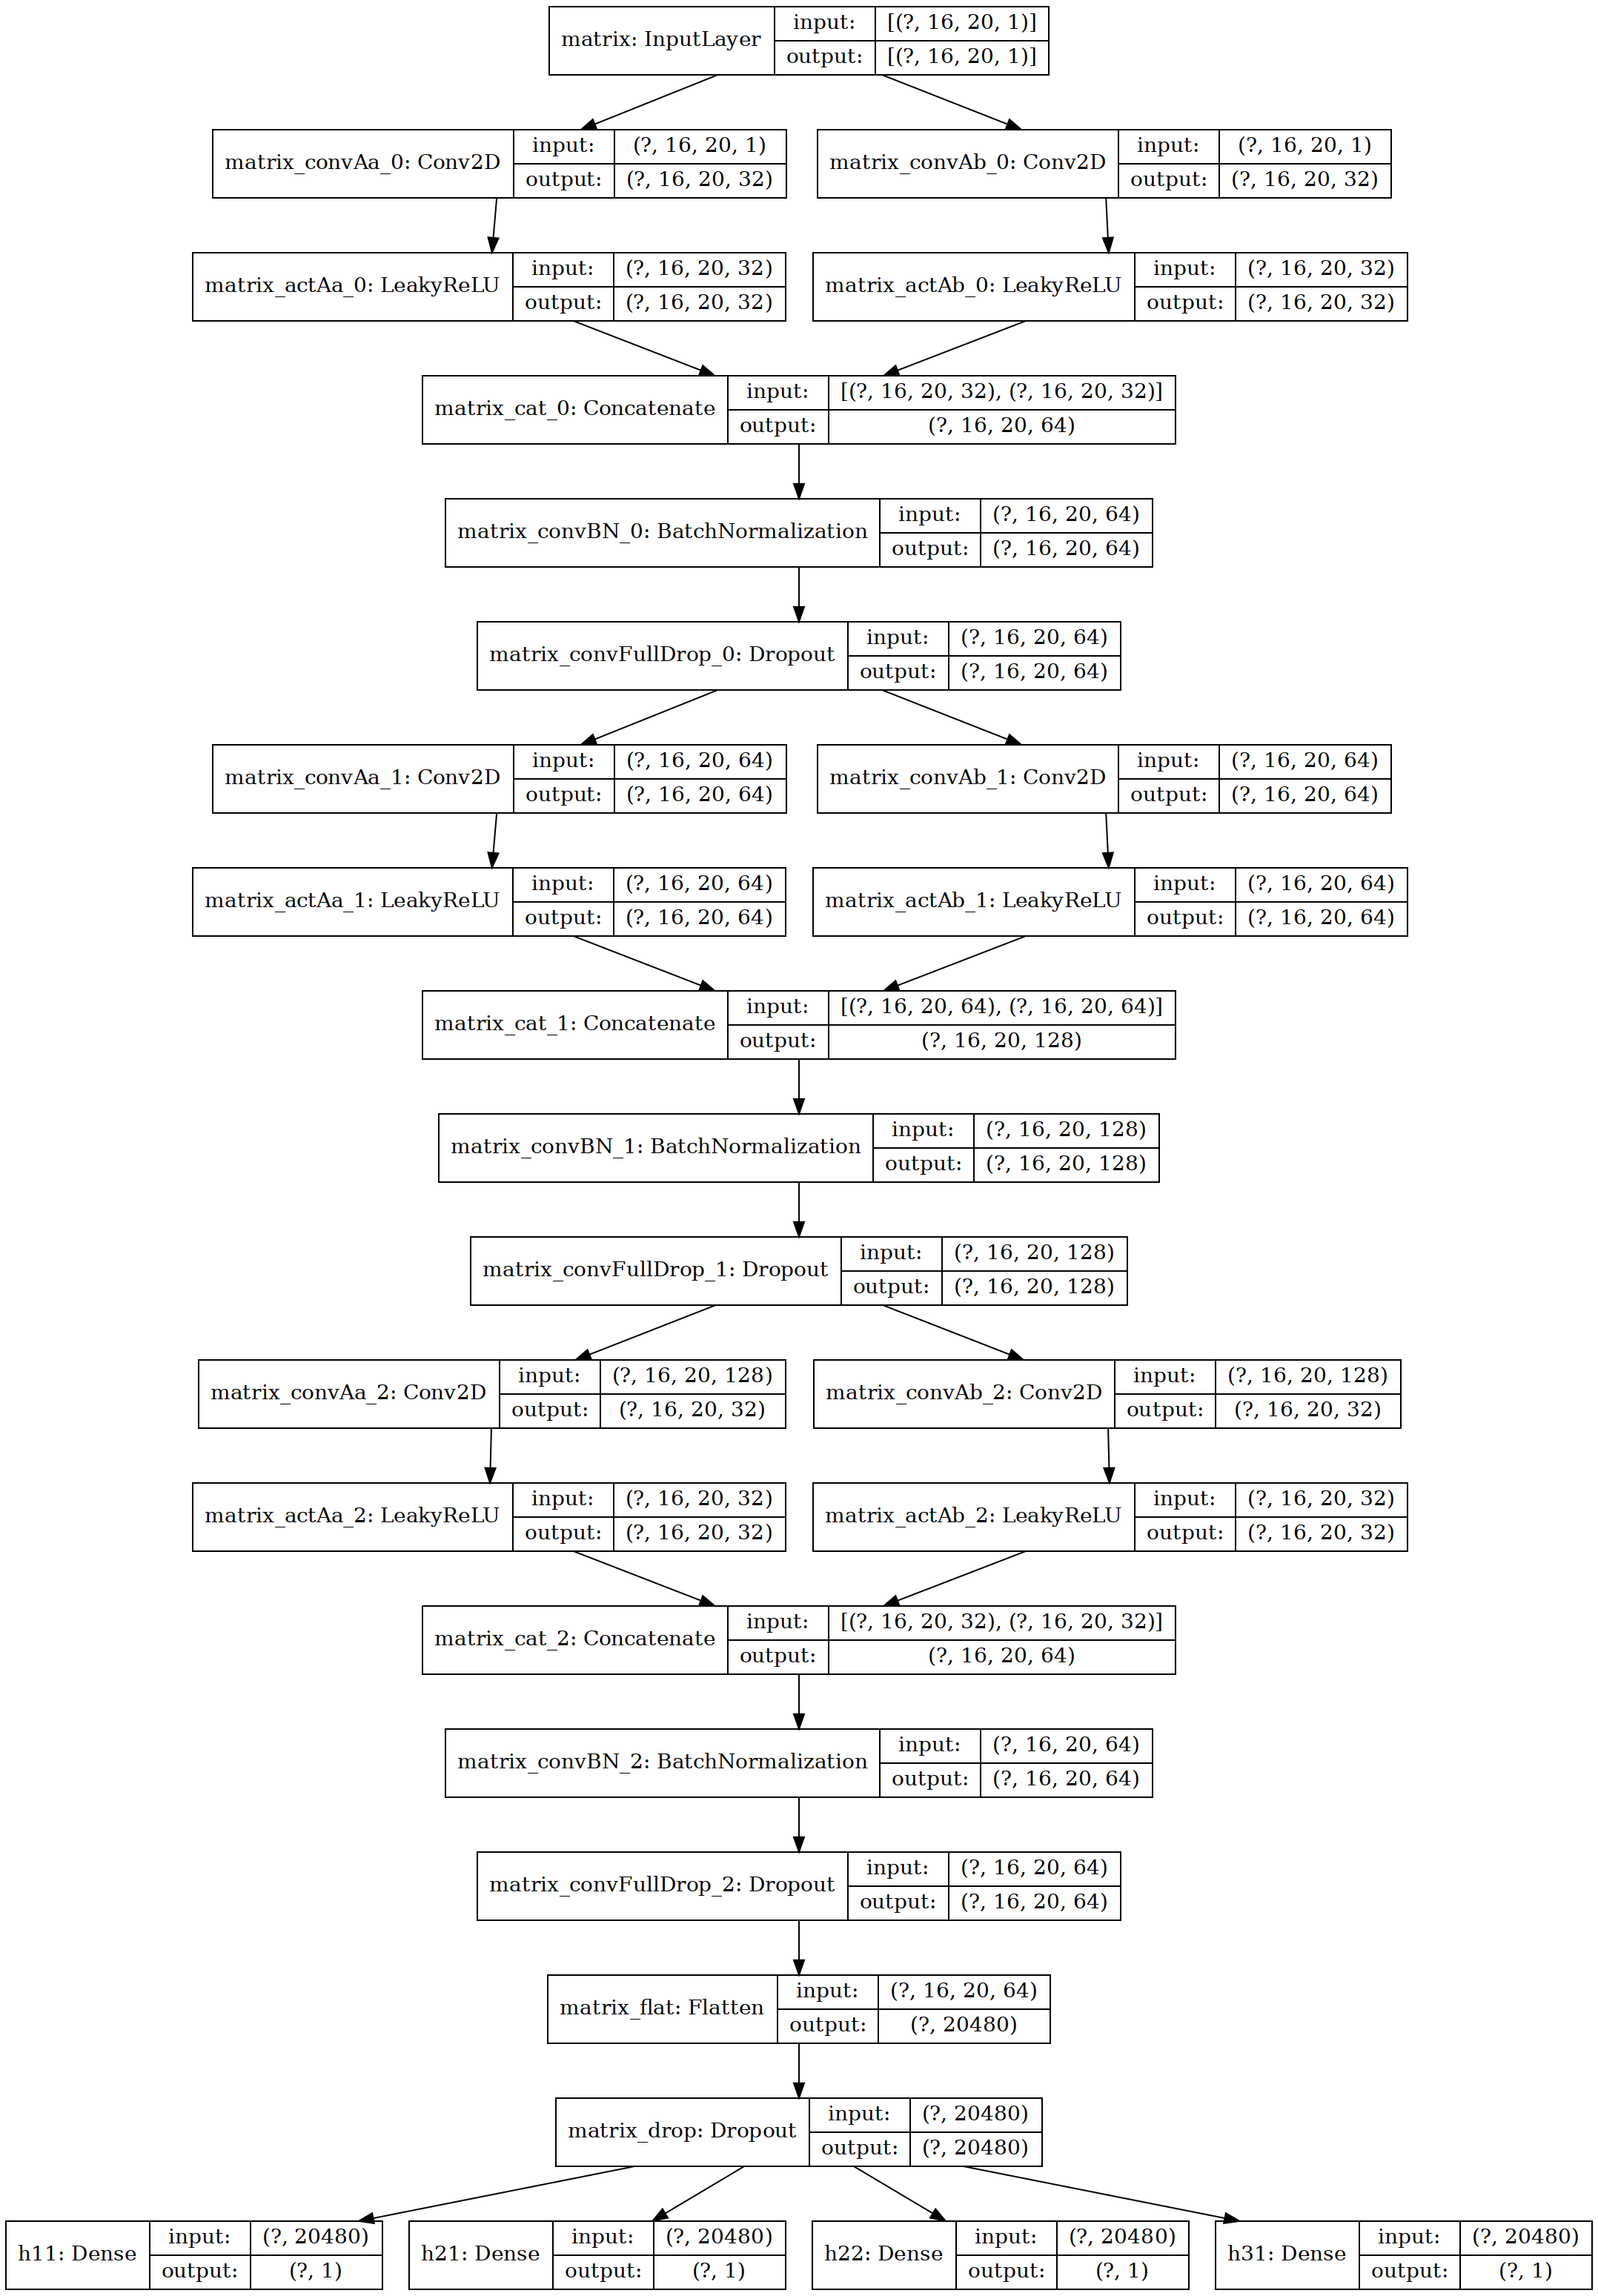

In [46]:
inception_graph = keras.utils.model_to_dot(inception, show_shapes=True, dpi=144)
inception_graph.write_pdf(os.path.join(img_dir, 'inception.pdf'))
Image(inception_graph.create_png(), width=480)

## Train the Model

The final set of parameters is specific to the fit function:

- `epochs`: the number of epochs of training,
- `batch_size`: the size of the mini batches,
- `reduce_lr`: number of epochs before reducing the learning rate,
- `reduce_lr_factor`: decay parameter of the learning rate,
- `stat_interval`: print statistics of training with this frequency in epochs (set -1 for more verbose output).

In [47]:
fit_data = {'epochs':           20,
            'batch_size':       32,
            'reduce_lr':        8,
            'reduce_lr_factor': 0.3,
            'stat_interval':    5
           }

with open(os.path.join(mod_dir, 'fit_data.json'), 'w') as f:
    json.dump(fit_data, f)

In [48]:
callbacks = model_checkpoints(list(inception.output.keys()),
                              root=mod_dir,
                              reduce_lr=fit_data['reduce_lr_factor'],
                              lr_patience=fit_data['reduce_lr'],
                              summary=fit_data['stat_interval']
                             )

inception_hst = inception.fit(x=X_train,
                              y=y_train,
                              batch_size=fit_data['batch_size'],
                              epochs=fit_data['epochs'],
                              verbose=0 if fit_data['stat_interval'] > 0 else 1,
                              callbacks=callbacks,
                              validation_data=(X_val, y_val)
                             )

Training has started. Callouts will be printed every 5 epochs.

Training epoch 1. Started on 12/12/2020 at 12:03:19.

    Average epoch training time: 00 hours, 03 minutes, 56 seconds

    loss = 90.108864
    h11_loss = 2.010857
    h21_loss = 4.220243
    h22_loss = 205.702606
    h31_loss = 16.023504
    h11_mean_squared_error = 2.010857
    h11_mean_absolute_error = 1.066121
    h21_mean_squared_error = 4.220243
    h21_mean_absolute_error = 0.817720
    h22_mean_squared_error = 205.702606
    h22_mean_absolute_error = 8.782041
    h31_mean_squared_error = 16.023504
    h31_mean_absolute_error = 2.722812
    val_loss = 39.961262
    val_h11_loss = 0.850001
    val_h21_loss = 4.206872
    val_h22_loss = 81.689941
    val_h31_loss = 11.345251
    val_h11_mean_squared_error = 0.850001
    val_h11_mean_absolute_error = 0.662476
    val_h21_mean_squared_error = 4.206872
    val_h21_mean_absolute_error = 0.821482
    val_h22_mean_squared_error = 81.689941
    val_h22_mean_absolute_error 

## Visualisation of the Training Data

We plot the metrics and the loss of the training for reference.

In [49]:
inception_hst = pd.DataFrame(inception_hst.history)
inception_hst.to_json(os.path.join(mod_dir, 'history.json'), orient='index')

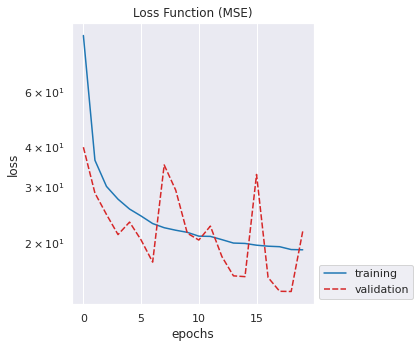

In [50]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst[['loss', 'val_loss']],
             palette=['tab:blue', 'tab:red'],
             ax=ax
            )
ax.set(title='Loss Function (MSE)',
       xlabel='epochs',
       ylabel='loss',
       yscale='log'
      )
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

savefig('inception_loss', fig, root=img_dir, show=True)

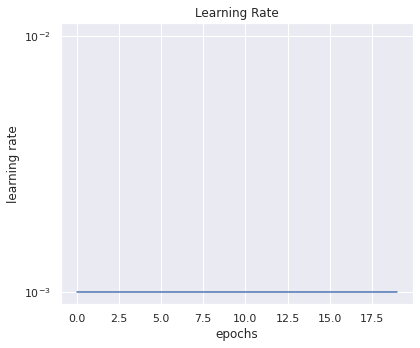

In [51]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst['lr'],
             ax=ax
            )
ax.set(title='Learning Rate',
       xlabel='epochs',
       ylabel='learning rate',
       yscale='log'
      )

savefig('inception_lr', fig, root=img_dir, show=True)